# Replication of Andrews et al. (2022): The Returns to College Major Choice

Project by Qilin Li, Spring 2026

---

This notebook contains my replication of the results from the following paper:

> Andrews, R. J., Imberman, S. A., Lovenheim, M. F., & Stange, K. M. (2022).  
> The Returns to College Major Choice: Average and Distributional Effects, Career Trajectories, and Earnings Variability.  
> NBER Working Paper No. 30331.

### Table of Contents

1. Introduction  
2. Data  
3. Empirical Framework  
4. Replication of Andrews et al. (2022)  
   4.1 Descriptive Statistics  
   4.2 Mean Earnings Differences Across Majors  
   4.3 Earnings by Major Category  
   4.4 Baseline Regression Results  
5. Extension and Robustness  
   5.1 Alternative Specifications  
   5.2 Log Earnings Specification  
6. Discussion  
7. Conclusion  
8. References

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## 1. Introduction

Differences in earnings across college majors are large and persistent in the U.S. labor market. Students’ choice of major is therefore one of the most consequential educational decisions they make. Understanding whether these differences reflect skill acquisition, labor market demand, or selection into fields of study is central to education and labor economics.

Andrews et al. (2022) examine the returns to college major choice using detailed administrative data from Texas. The authors document substantial variation in average earnings across majors and further analyze how these differences vary across the earnings distribution, over career trajectories, and in terms of earnings variability. Their findings suggest that major choice plays an important role in shaping both short-run and long-run labor market outcomes.

In this notebook, I replicate the core results of Andrews et al. (2022), focusing on differences in mean earnings across college majors. Using publicly available data from the American Community Survey (ACS), I estimate the association between major choice and median earnings and compare the patterns observed in this dataset to the findings reported in the original paper. While this replication does not reproduce the distributional or lifecycle analyses conducted by the authors, it aims to assess whether the central result — that earnings differ substantially across majors — is robust in alternative data.

### Main Variables

The main variables used in this replication are summarized below.

In [4]:
main_vars = pd.DataFrame(
    {
        "Category": [
            "Outcome Variable",
            "Main Explanatory Variable",
            "Control Variable",
        ],
        "Variable": [
            "Median Earnings",
            "College Major / Major Category",
            "Unemployment Rate",
        ],
        "Description": [
            "Median annual earnings by college major",
            "Field of study (individual major or grouped category)",
            "Unemployment rate by major",
        ],
    }
)

main_vars

,Category,Variable,Description
0,Outcome Variable,Median Earnings,Median annual earnings by college major
1,Main Explanatory Variable,College Major / Major Category,Field of study (individual major or grouped ca...
2,Control Variable,Unemployment Rate,Unemployment rate by major


## 2. Data

This replication uses the “College Majors” dataset derived from the American Community Survey (ACS) 2010–2012. The dataset reports labor market outcomes by college major, including median earnings, unemployment rates, and employment composition.

The unit of observation is a college major. Each observation represents aggregated labor market outcomes for individuals with that field of study.

The primary outcome variable is **Median earnings**, which measures annual median earnings by major. The key explanatory variable is **college major** (or major category).

In [5]:
df = pd.read_csv("data/all-ages.csv")
df.head()

,Major_code,Major,Major_category,Total,Employed,Employed_full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th
0,1100,GENERAL AGRICULTURE,Agriculture & Natural Resources,128148,90245,74078,2423,0.026147,50000,34000,80000.0
1,1101,AGRICULTURE PRODUCTION AND MANAGEMENT,Agriculture & Natural Resources,95326,76865,64240,2266,0.028636,54000,36000,80000.0
2,1102,AGRICULTURAL ECONOMICS,Agriculture & Natural Resources,33955,26321,22810,821,0.030248,63000,40000,98000.0
3,1103,ANIMAL SCIENCES,Agriculture & Natural Resources,103549,81177,64937,3619,0.042679,46000,30000,72000.0
4,1104,FOOD SCIENCE,Agriculture & Natural Resources,24280,17281,12722,894,0.049188,62000,38500,90000.0


In [11]:
df.shape
df.describe()

,Major_code,Total,Employed,Employed_full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th
count,173.000000,1.730000e+02,1.730000e+02,1.730000e+02,173.000000,173.000000,173.000000,173.000000,173.000000
mean,3879.815029,2.302566e+05,1.661620e+05,1.263078e+05,9725.034682,0.057355,56816.184971,38697.109827,82506.358382
std,1687.753140,4.220685e+05,3.073244e+05,2.424254e+05,18022.040192,0.019177,14706.226865,9414.524761,20805.330126
min,1100.000000,2.396000e+03,1.492000e+03,1.093000e+03,0.000000,0.000000,35000.000000,24900.000000,45800.000000
25%,2403.000000,2.428000e+04,1.728100e+04,1.272200e+04,1101.000000,0.046261,46000.000000,32000.000000,70000.000000
50%,3608.000000,7.579100e+04,5.656400e+04,3.961300e+04,3619.000000,0.054719,53000.000000,36000.000000,80000.000000
75%,5503.000000,2.057630e+05,1.428790e+05,1.110250e+05,8862.000000,0.069043,65000.000000,42000.000000,95000.000000
max,6403.000000,3.123510e+06,2.354398e+06,1.939384e+06,147261.000000,0.156147,125000.000000,78000.000000,210000.000000


The dataset contains 173 college majors. Median earnings vary substantially across majors. 
The average median earnings are approximately $56,800, with values ranging from about $35,000 to $125,000. 
This large dispersion suggests that college major choice is strongly associated with labor market outcomes.

In [12]:
df.sort_values("Median", ascending=False)[["Major", "Median"]].head(10)

,Major,Median
59,PETROLEUM ENGINEERING,125000
154,PHARMACY PHARMACEUTICAL SCIENCES AND ADMINISTR...,106000
57,NAVAL ARCHITECTURE AND MARINE ENGINEERING,97000
55,METALLURGICAL ENGINEERING,96000
58,NUCLEAR ENGINEERING,95000
56,MINING AND MINERAL ENGINEERING,92000
97,MATHEMATICS AND COMPUTER SCIENCE,92000
48,ELECTRICAL ENGINEERING,88000
45,CHEMICAL ENGINEERING,86000
51,GEOLOGICAL AND GEOPHYSICAL ENGINEERING,85000


The highest-earning majors are concentrated in engineering and quantitative fields. 
Petroleum Engineering has the highest median earnings ($125,000), followed by Pharmacy and several engineering disciplines. 
These results suggest that STEM-related majors are associated with substantially higher labor market returns.

In [13]:
df.sort_values("Median")[["Major", "Median"]].head(10)

,Major,Median
88,NEUROSCIENCE,35000
31,EARLY CHILDHOOD EDUCATION,35300
145,STUDIO ARTS,37600
124,HUMAN SERVICES AND COMMUNITY ORGANIZATION,38000
117,COUNSELING PSYCHOLOGY,39000
77,LIBRARY SCIENCE,40000
28,ELEMENTARY EDUCATION,40000
24,COSMETOLOGY SERVICES AND CULINARY ARTS,40000
115,EDUCATIONAL PSYCHOLOGY,40000
74,COMPOSITION AND RHETORIC,40000


In contrast, the lowest-earning majors are concentrated in education, arts, and social service fields. 
Median earnings in these majors range between approximately $35,000 and $40,000. 
The gap between the highest- and lowest-paying majors exceeds $90,000, indicating substantial heterogeneity in labor market returns across fields of study.

In [14]:
df.groupby("Major_category")["Median"].mean().sort_values(ascending=False)

Major_category
Engineering                            77758.620690
Computers & Mathematics                66272.727273
Physical Sciences                      62400.000000
Business                               60615.384615
Health                                 56458.333333
Agriculture & Natural Resources        55000.000000
Social Science                         53222.222222
Law & Public Policy                    52800.000000
Industrial Arts & Consumer Services    52642.857143
Biology & Life Science                 50821.428571
Communications & Journalism            49500.000000
Humanities & Liberal Arts              46080.000000
Psychology & Social Work               44555.555556
Education                              43831.250000
Arts                                   43525.000000
Interdisciplinary                      43000.000000
Name: Median, dtype: float64

At the major category level, Engineering has the highest average median earnings (approximately $77,800), followed by Computers & Mathematics and Physical Sciences. 
In contrast, Education and Arts-related fields have substantially lower average earnings, around $43,000–$44,000. 

These descriptive patterns confirm that earnings differ widely across fields of study, consistent with the central findings of Andrews et al. (2022).

## 3. Empirical Framework

Differences in earnings across college majors can be understood through the lens of human capital theory. According to this framework, individuals invest in education to acquire skills that increase productivity and future earnings. Different majors provide different types of skills, which may be valued differently in the labor market.

Earnings differences may arise from several mechanisms. First, some fields of study may generate higher productivity due to technical or quantitative skill acquisition. Second, labor market demand may differ across sectors, leading to wage premiums in high-demand industries such as engineering or computing. Third, selection may play a role, as students with higher ability or stronger quantitative backgrounds may disproportionately choose certain majors.

Andrews et al. (2022) examine whether these earnings differences persist across the earnings distribution and over the lifecycle. In this replication, I focus on the central empirical finding that median earnings differ substantially across majors.

To examine the relationship between college major and earnings, I estimate a simple cross-sectional regression model:

$$
\log(Median_i) = \alpha + \beta MajorCategory_i + \gamma UnemploymentRate_i + \epsilon_i
$$

where:

- $Median_i$ denotes median earnings for major $i$,
- $MajorCategory_i$ represents major category indicators,
- $UnemploymentRate_i$ captures the unemployment rate associated with each major,
- $\beta$ measures average earnings differences across major categories,
- $\gamma$ controls for labor market conditions across fields of study.

Including unemployment rates allows the analysis to account for variation in labor market demand across majors, since fields with lower unemployment may also command higher wages.

This specification does not establish causal effects of major choice, but it provides descriptive evidence on how labor market outcomes vary systematically across fields of study.

### 4.1 Descriptive Statistics

I begin by examining the basic characteristics of the dataset. The College Majors dataset contains information on labor market outcomes across 173 different college majors derived from the American Community Survey (ACS). Each observation represents an aggregated field of study rather than an individual worker.

The dataset reports several labor market indicators, including the number of individuals employed in each field, unemployment rates, and measures of the earnings distribution such as the median, 25th percentile, and 75th percentile earnings.

Table 1 presents summary statistics for the key variables used in the analysis. Median annual earnings across majors average around \$56,800, with substantial variation across fields of study. The lowest median earnings are around \$35,000, while the highest exceed \$120,000. This wide dispersion suggests that college major choice is strongly associated with labor market outcomes.

Unemployment rates also vary across majors, reflecting differences in labor demand across fields. Majors associated with technical or quantitative skills tend to have lower unemployment and higher earnings, while some fields in the arts or social services exhibit lower earnings and slightly higher unemployment rates.

These descriptive statistics provide initial evidence that both earnings and employment outcomes differ substantially across majors, motivating the empirical analysis that follows.

In [6]:
df[["Median", "Unemployment_rate", "Employed", "Total"]].describe()

,Median,Unemployment_rate,Employed,Total
count,173.000000,173.000000,1.730000e+02,1.730000e+02
mean,56816.184971,0.057355,1.661620e+05,2.302566e+05
std,14706.226865,0.019177,3.073244e+05,4.220685e+05
min,35000.000000,0.000000,1.492000e+03,2.396000e+03
25%,46000.000000,0.046261,1.728100e+04,2.428000e+04
50%,53000.000000,0.054719,5.656400e+04,7.579100e+04
75%,65000.000000,0.069043,1.428790e+05,2.057630e+05
max,125000.000000,0.156147,2.354398e+06,3.123510e+06


The summary statistics confirm that labor market outcomes vary substantially across college majors. 
The average median earnings across majors are approximately \$56,800, with values ranging from about \$35,000 to \$125,000. 
This large dispersion indicates that the choice of major is strongly associated with earnings outcomes.

Unemployment rates also differ across fields of study. 
The average unemployment rate across majors is about 5.7 percent, with some majors experiencing much lower unemployment and others facing higher labor market risk. 
These patterns suggest that both earnings and employment outcomes vary systematically across majors.

### 4.2 Mean Earnings Differences Across Majors

To further examine how earnings differ across fields of study, I compare median earnings across individual college majors. 
Sorting majors by their median earnings provides a clearer view of which fields are associated with the highest and lowest labor market returns.

Table 2 reports the majors with the highest median earnings, while Table 3 reports the majors with the lowest median earnings. 
These comparisons illustrate the substantial variation in earnings outcomes across fields of study.

In [7]:
top_majors = df.sort_values("Median", ascending=False)[["Major", "Major_category", "Median"]].head(10)
top_majors

,Major,Major_category,Median
59,PETROLEUM ENGINEERING,Engineering,125000
154,PHARMACY PHARMACEUTICAL SCIENCES AND ADMINISTR...,Health,106000
57,NAVAL ARCHITECTURE AND MARINE ENGINEERING,Engineering,97000
55,METALLURGICAL ENGINEERING,Engineering,96000
58,NUCLEAR ENGINEERING,Engineering,95000
56,MINING AND MINERAL ENGINEERING,Engineering,92000
97,MATHEMATICS AND COMPUTER SCIENCE,Computers & Mathematics,92000
48,ELECTRICAL ENGINEERING,Engineering,88000
45,CHEMICAL ENGINEERING,Engineering,86000
51,GEOLOGICAL AND GEOPHYSICAL ENGINEERING,Engineering,85000


In [8]:
bottom_majors = df.sort_values("Median")[["Major", "Major_category", "Median"]].head(10)
bottom_majors

,Major,Major_category,Median
88,NEUROSCIENCE,Biology & Life Science,35000
31,EARLY CHILDHOOD EDUCATION,Education,35300
145,STUDIO ARTS,Arts,37600
124,HUMAN SERVICES AND COMMUNITY ORGANIZATION,Psychology & Social Work,38000
117,COUNSELING PSYCHOLOGY,Psychology & Social Work,39000
77,LIBRARY SCIENCE,Education,40000
28,ELEMENTARY EDUCATION,Education,40000
24,COSMETOLOGY SERVICES AND CULINARY ARTS,Industrial Arts & Consumer Services,40000
115,EDUCATIONAL PSYCHOLOGY,Psychology & Social Work,40000
74,COMPOSITION AND RHETORIC,Humanities & Liberal Arts,40000


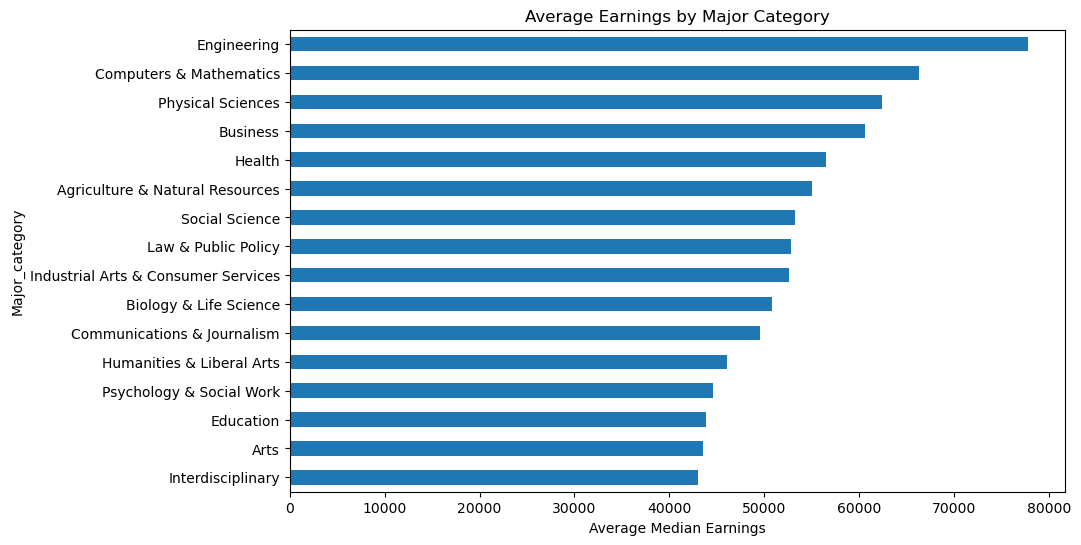

In [11]:
category_earnings = df.groupby("Major_category")["Median"].mean().sort_values()

plt.figure(figsize=(10,6))
category_earnings.plot(kind="barh")
plt.xlabel("Average Median Earnings")
plt.title("Average Earnings by Major Category")
plt.show()

The figure shows clear differences in average earnings across major categories. 
Majors in engineering, computer science, and physical sciences tend to have the highest earnings, while fields in education, arts, and social services generally have lower median earnings.

These patterns are consistent with the idea that labor market demand and skill specialization vary across fields of study. 
Majors that emphasize technical or quantitative skills often command higher wages in the labor market.

### 4.3 Earnings Distribution Across Major Categories

While average earnings provide a useful summary, they may mask variation within fields of study. To better understand the dispersion of earnings across majors, I examine the distribution of median earnings by major category.

Figure 2 presents a boxplot of median earnings across major categories. The boxplot shows the median, interquartile range, and overall dispersion of earnings for majors within each category.

This visualization highlights how earnings outcomes vary not only between categories but also within them.

<Figure size 1200x600 with 0 Axes>

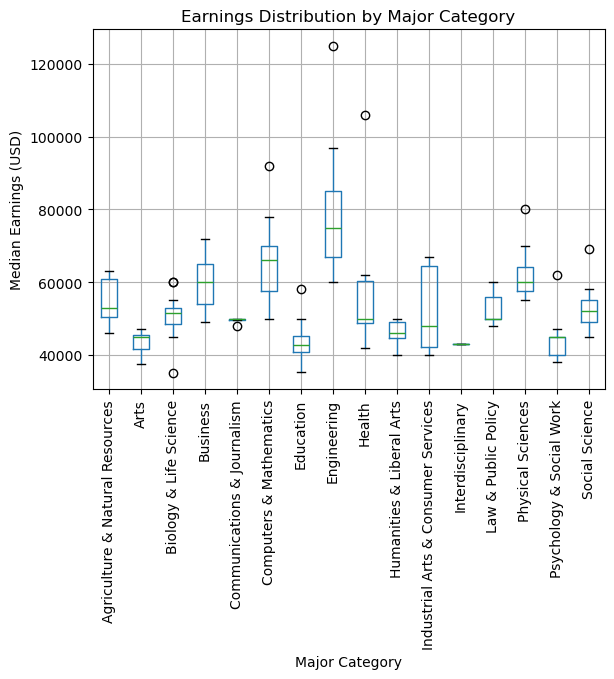

In [14]:
plt.figure(figsize=(12,6))

df.boxplot(column="Median", by="Major_category", rot=90)

plt.title("Earnings Distribution by Major Category")
plt.suptitle("")
plt.ylabel("Median Earnings (USD)")
plt.xlabel("Major Category")

plt.show()

The boxplot reveals substantial variation in earnings across major categories. Engineering and computer-related fields generally have higher median earnings, with relatively concentrated distributions.

In contrast, fields such as arts, education, and humanities tend to have lower earnings levels. Some categories also display wider dispersion, indicating that earnings outcomes vary considerably across individual majors within the same category.

These results reinforce the earlier descriptive findings that college major choice is strongly associated with labor market outcomes.

### 4.4 Baseline Regression Results

To quantify the relationship between college major and earnings, I estimate a simple cross-sectional regression model where the dependent variable is the logarithm of median earnings.

Using the logarithm of earnings allows the coefficients to be interpreted approximately as percentage differences. The regression includes indicators for major categories as well as the unemployment rate associated with each major.

This specification allows us to examine whether earnings differences across majors persist after accounting for variation in labor market conditions.

In [16]:
df["log_median"] = np.log(df["Median"])
model = smf.ols(
    "log_median ~ C(Major_category) + Unemployment_rate",
    data=df
).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_median   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.635
Method:                 Least Squares   F-statistic:                     19.67
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.19e-29
Time:                        15:09:40   Log-Likelihood:                 99.976
No. Observations:                 173   AIC:                            -166.0
Df Residuals:                     156   BIC:                            -112.3
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
============================================================================================================================
                                                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                   10.9876      0.053    205.527      0.000      10.882      11.093
C(Major_category)[T.Arts]                                   -0.1364      0.076     -1.791      0.075      -0.287       0.014
C(Major_category)[T.Biology & Life Science]                 -0.0607      0.060     -1.018      0.310      -0.179       0.057
C(Major_category)[T.Business]                                0.1254      0.061      2.053      0.042       0.005       0.246
C(Major_category)[T.Communications & Journalism]            -0.0417      0.087     -0.478      0.633      -0.214       0.131
C(Major_category)[T.Computers & Mathematics]                 0.2174      0.064      3.392      0.001       0.091       0.344
C(Major_category)[T.Education]                              -0.2134      0.058     -3.688      0.000      -0.328      -0.099
C(Major_category)[T.Engineering]                             0.3593      0.053      6.775      0.000       0.255       0.464
C(Major_category)[T.Health]                                  0.0162      0.061      0.264      0.792      -0.105       0.138
C(Major_category)[T.Humanities & Liberal Arts]              -0.1151      0.062     -1.850      0.066      -0.238       0.008
C(Major_category)[T.Industrial Arts & Consumer Services]    -0.0239      0.072     -0.333      0.740      -0.166       0.118
C(Major_category)[T.Interdisciplinary]                      -0.1662      0.152     -1.091      0.277      -0.467       0.135
C(Major_category)[T.Law & Public Policy]                     0.0170      0.081      0.210      0.834      -0.143       0.177
C(Major_category)[T.Physical Sciences]                       0.1551      0.065      2.392      0.018       0.027       0.283
C(Major_category)[T.Psychology & Social Work]               -0.1400      0.071     -1.965      0.051      -0.281       0.001
C(Major_category)[T.Social Science]                          0.0167      0.068      0.244      0.807      -0.118       0.152
Unemployment_rate                                           -1.9724      0.721     -2.736      0.007      -3.397      -0.548
==============================================================================
Omnibus:                       34.834   Durbin-Watson:                   1.876
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               74.693
Skew:                           0.902   Prob(JB):                     6.03e-17
Kurtosis:                       5.666   Cond. No.                         69.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Using the logarithm of earnings provides two main advantages. 
First, the log transformation allows the regression coefficients to be interpreted approximately as percentage differences in earnings across major categories. 
Second, earnings distributions are typically right-skewed, with a small number of majors having very high earnings. Taking the logarithm reduces this skewness and makes the regression model more stable.

Therefore, the dependent variable in the baseline regression is the logarithm of median earnings across majors.
Because the dependent variable is in logarithmic form, the estimated coefficients can be interpreted approximately as percentage differences in earnings.

The regression results indicate that earnings differ substantially across major categories. 
Relative to the omitted baseline category, majors in engineering and computer-related fields are associated with significantly higher earnings. 
For example, the coefficient for engineering is positive and statistically significant, indicating that engineering majors tend to earn substantially more than the baseline category.

In contrast, majors in education and arts are associated with lower earnings. 
These findings are consistent with the descriptive statistics presented earlier, which showed that technical and quantitative fields tend to have higher earnings.

The unemployment rate is negatively associated with earnings and statistically significant. 
This suggests that majors with higher unemployment rates tend to have lower median earnings, reflecting weaker labor market demand.

Overall, the regression confirms the earlier descriptive results that college major choice is strongly associated with labor market outcomes.

### 5.1 Alternative Specifications

To assess the robustness of the baseline results, I estimate an alternative specification that excludes the unemployment rate control. 
This allows us to examine whether the estimated differences in earnings across majors are sensitive to the inclusion of labor market conditions.

The alternative regression model is:

$$
\log(Median_i) = \alpha + \beta MajorCategory_i + \epsilon_i
$$

Comparing this specification with the baseline model helps evaluate whether the estimated earnings differences across majors remain stable when fewer controls are included.

In [17]:
alt_model = smf.ols(
    "log_median ~ C(Major_category)",
    data=df
).fit()

alt_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_median   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     19.67
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           8.63e-29
Time:                        15:15:37   Log-Likelihood:                 95.923
No. Observations:                 173   AIC:                            -159.8
Df Residuals:                     157   BIC:                            -109.4
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
============================================================================================================================
                                                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                   10.9096      0.046    236.469      0.000      10.818      11.001
C(Major_category)[T.Arts]                                   -0.2311      0.069     -3.340      0.001      -0.368      -0.094
C(Major_category)[T.Biology & Life Science]                 -0.0812      0.060     -1.344      0.181      -0.200       0.038
C(Major_category)[T.Business]                                0.0960      0.061      1.564      0.120      -0.025       0.217
C(Major_category)[T.Communications & Journalism]            -0.1000      0.086     -1.158      0.248      -0.270       0.070
C(Major_category)[T.Computers & Mathematics]                 0.1782      0.064      2.796      0.006       0.052       0.304
C(Major_category)[T.Education]                              -0.2276      0.059     -3.870      0.000      -0.344      -0.111
C(Major_category)[T.Engineering]                             0.3375      0.054      6.308      0.000       0.232       0.443
C(Major_category)[T.Health]                                  0.0012      0.062      0.019      0.985      -0.122       0.125
C(Major_category)[T.Humanities & Liberal Arts]              -0.1740      0.060     -2.921      0.004      -0.292      -0.056
C(Major_category)[T.Industrial Arts & Consumer Services]    -0.0613      0.072     -0.853      0.395      -0.203       0.081
C(Major_category)[T.Interdisciplinary]                      -0.2406      0.153     -1.572      0.118      -0.543       0.062
C(Major_category)[T.Law & Public Policy]                    -0.0388      0.080     -0.486      0.628      -0.197       0.119
C(Major_category)[T.Physical Sciences]                       0.1256      0.065      1.925      0.056      -0.003       0.254
C(Major_category)[T.Psychology & Social Work]               -0.2156      0.067     -3.216      0.002      -0.348      -0.083
C(Major_category)[T.Social Science]                         -0.0348      0.067     -0.520      0.604      -0.167       0.098
==============================================================================
Omnibus:                       36.063   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               83.313
Skew:                           0.903   Prob(JB):                     8.11e-19
Kurtosis:                       5.881   Cond. No.                         18.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The results from the alternative specification are broadly consistent with the baseline regression. 
Majors associated with technical and quantitative skills continue to show higher earnings, while fields such as arts, education, and humanities remain associated with lower earnings.

For example, the coefficient for engineering is positive and statistically significant, indicating that engineering majors tend to earn substantially more than the omitted baseline category. 
Similarly, majors in computers and mathematics also exhibit higher earnings.

In contrast, majors in arts and education have negative and statistically significant coefficients, suggesting lower earnings relative to the baseline category. 
Overall, the similarity between this specification and the baseline model suggests that the observed earnings differences across majors are not driven solely by differences in unemployment rates.

### 5.2 Alternative Specification

As a robustness check, I estimate an alternative specification that excludes the unemployment rate control variable. This specification focuses solely on the relationship between college major and earnings.

The results remain broadly similar to the baseline regression. Majors such as engineering and computer-related fields continue to show higher earnings relative to the reference category, while majors such as arts and education tend to have lower earnings.

This suggests that the relationship between college major and earnings is not driven solely by differences in unemployment rates across fields of study.

## 6 Discussion

The results show that college major is strongly associated with differences in earnings. 
Majors that emphasize technical and quantitative skills, such as engineering and computer science, tend to have higher median earnings. 
In contrast, majors such as arts, education, and social services are associated with lower earnings.

These differences may reflect variation in labor market demand and skill specialization across fields of study. 
Fields that provide technical skills are often more directly connected to high-paying industries.

However, the results should be interpreted with caution. 
The analysis is based on cross-sectional data and does not fully account for individual characteristics such as ability, preferences, or experience. 
Students with stronger quantitative backgrounds may be more likely to select into certain majors, which may partly explain the observed earnings differences.

## 7 Conclusion

This project replicates the central finding of Andrews et al. (2022) that earnings differ substantially across college majors. 
Using data from the American Community Survey, the analysis shows that majors in engineering, computer science, and physical sciences tend to have higher median earnings, while majors in arts and education tend to have lower earnings.

Regression analysis confirms that these differences remain even after controlling for unemployment rates across majors. 
Additional robustness checks show that the results are broadly consistent across alternative specifications.

Overall, the results suggest that the choice of college major plays an important role in shaping labor market outcomes.

## 8 References

Andrews, Rodney J., Scott A. Imberman, Michael F. Lovenheim, and Kevin M. Stange. 2022.  
"The Returns to College Major Choice: Average and Distributional Effects, Career Trajectories, and Earnings Variability."  
NBER Working Paper No. 30331.

Fivethirtyeight. 2015.  
"College Majors Dataset."  
Available on Kaggle: https://www.kaggle.com/datasets/tunguz/college-majors

Altonji, Joseph G., Erica Blom, and Costas Meghir. 2012.  
"Heterogeneity in Human Capital Investments: High School Curriculum, College Major, and Careers."  
Annual Review of Economics 4: 185–223.